In [1]:
import sys, os

# Path to your project root (the folder that contains pointmaze/, rpmml_project/, etc.)
PROJECT_ROOT = "/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PYTHONPATH updated with:", PROJECT_ROOT)

PYTHONPATH updated with: /scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
from eqnet_independent_copy import EqNet, GaussianDiffusion, DiffuserTrainer, DiffuserPlanner, CompositeReward, expand_spline_from_skip_list, StartReachingReward, GoalReachingReward, SkipTotalTimeSkipPenalty, CurvaturePenalty, OfflineSkipDataset
from point_maze_skip import MinariTrajectoryDatasetWithPseudoActions
import torch
from matplotlib.patches import Rectangle
import mujoco

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

USE_POSITIONAL_ENCODING = False

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print(f"Positional Encoding: {USE_POSITIONAL_ENCODING}")
print("Architecture: Local convolutions (no downsampling) for shift equivariance")
print("Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)")

    # ========================================================================
    # DATA
    # ========================================================================

# Use pseudo-action dataset
dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/medium-v2", horizon=32, n_chunks_frac= 0.5
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Using device: cuda

EQ-NET CONFIGURATION
Positional Encoding: False
Architecture: Local convolutions (no downsampling) for shift equivariance
Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)

Dataset size: 363160 trajectory windows
Trajectory dim (pos+skip): 3


In [4]:
# ========================================================================
    # MODEL
    # ========================================================================

eqnet = EqNet(
        state_dim=dataset.traj_dim,
        hidden_dim=128,
        time_dim=32,
        n_layers=10,  # Deep but local
    )

diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")



Model parameters: 1,506,179


In [6]:
# ========================================================================
# TRAINING
# ========================================================================

trainer = DiffuserTrainer(
        model = eqnet,
        diffusion = diffusion,
        dataset=dataset,
        device = device,
    )

TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=100, save_every=1)
else:
    print("\nLoading pre-trained model...")
    try:
        trainer.load("/scratch/network/dd6849/rpmml-project/checkpoints/diffuser_flat_eqnet_independent_epoch_100_fixed.pt")
        print("Loaded checkpoint successfully")
    except:
        print("No checkpoint found, using random initialization")

trainer.use_ema_for_inference()


Loading pre-trained model...
Loaded checkpoint successfully
Switched to EMA parameters for inference


In [30]:
# ========================================================================
# PLANNING
# ========================================================================

planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([-0.5, -1.5, 0, 0])
goal = np.array([-1.5, 1.5])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.0),
    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=32,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)
coarse, = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:2]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)
print(pos_dense)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [-0.40039339 -1.46668374]
Start (target): [-0.5 -1.5]
Start error: 0.1050
End: [-1.49982171  1.49966205]
Goal: [-1.5  1.5]
Goal error: 0.0004

EXPERIMENTS COMPLETE
[[-0.40039339 -1.46668374]
 [-0.40021891 -1.47143396]
 [-0.3943539  -1.47555248]
 [-0.37942039 -1.47544237]
 [-0.37387783 -1.47327939]
 [-0.39472588 -1.46482278]
 [-0.3948367  -1.46041957]
 [-0.3690031  -1.46260951]
 [-0.33219047 -1.46380891]
 [-0.26487964 -1.46313319]
 [-0.1975688  -1.46245746]
 [-0.15964474 -1.46288144]
 [-0.14954445 -1.46386322]
 [-0.13576717 -1.46526365]
 [-0.11692756 -1.46756924]
 [-0.09664387 -1.46937703]
 [-0.07992356 -1.47047698]
 [-0.05172296 -1.47150025]
 [ 0.01119817 -1.47421043]
 [ 0.0741193  -1.47692061]
 [ 0.11450573 -1.47482411]
 [ 0.13452547 -1.4697313 ]
 [ 0.15454521 -1.4646385 ]
 [ 0.16400784 -1.46084445]
 [ 0.16388085 -1.4592519 ]
 [ 0.16517509 -1.45608484]
 [ 0.17717689 -1.4605634 ]
 [ 0.17417095 -

In [31]:
env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model = env.model
mj_data = env.data

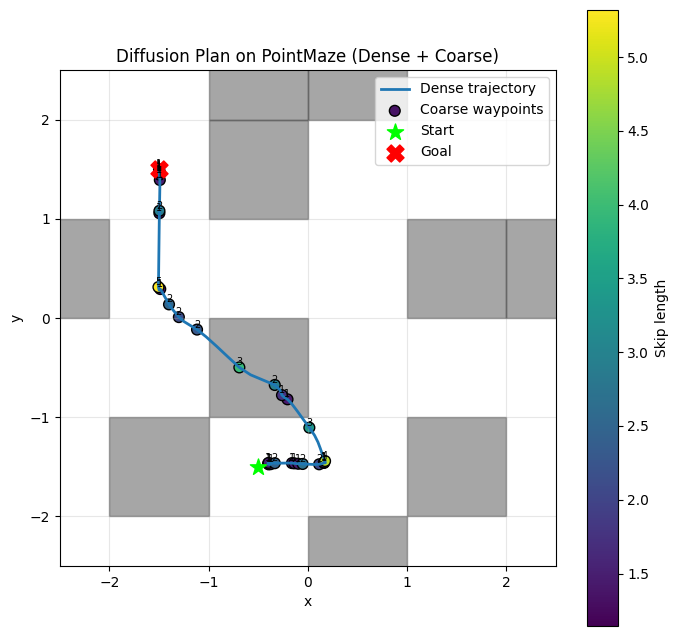

In [32]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# ===========================================================
# 1) Dense trajectory
# ===========================================================
ax.plot(
    pos_dense[:, 0],
    pos_dense[:, 1],
    linewidth=2,
    color="tab:blue",
    label="Dense trajectory"
)

# ===========================================================
# 2) Coarse waypoints (colored by skip)
# ===========================================================
sc = ax.scatter(
    coarse_pos[:, 0],
    coarse_pos[:, 1],
    c=coarse_skip,
    s=60,
    cmap="viridis",
    edgecolors="k",
    label="Coarse waypoints"
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Skip length")

# Annotate skip values
for i, (x, y) in enumerate(coarse_pos):
    ax.text(x, y, f"{int(coarse_skip[i])}", fontsize=7, ha="center", va="bottom")

# ===========================================================
# 3) Start and Goal
# ===========================================================
ax.scatter(current[0], current[1], s=150, marker="*", color="lime",  label="Start")
ax.scatter(goal[0],    goal[1],    s=150, marker="X", color="red",   label="Goal")

# ===========================================================
# 4) Render MuJoCo maze walls
# ===========================================================
for geom_id in range(mj_model.ngeom):

    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

    if name is None or ("block" not in name):
        continue

    pos = mj_model.geom_pos[geom_id]      # (x,y,z) center
    size = mj_model.geom_size[geom_id]    # half sizes (hx,hy,hz)

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# ===========================================================
# Final styling
# ===========================================================
ax.set_title("Diffusion Plan on PointMaze (Dense + Coarse)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# Mazes are usually within [-2.5, 2.5]
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.show()


Running 10 planning attempts...

 → Run 1/10
 → Run 2/10
 → Run 3/10
 → Run 4/10
 → Run 5/10
 → Run 6/10
 → Run 7/10
 → Run 8/10
 → Run 9/10
 → Run 10/10

All planning runs complete.



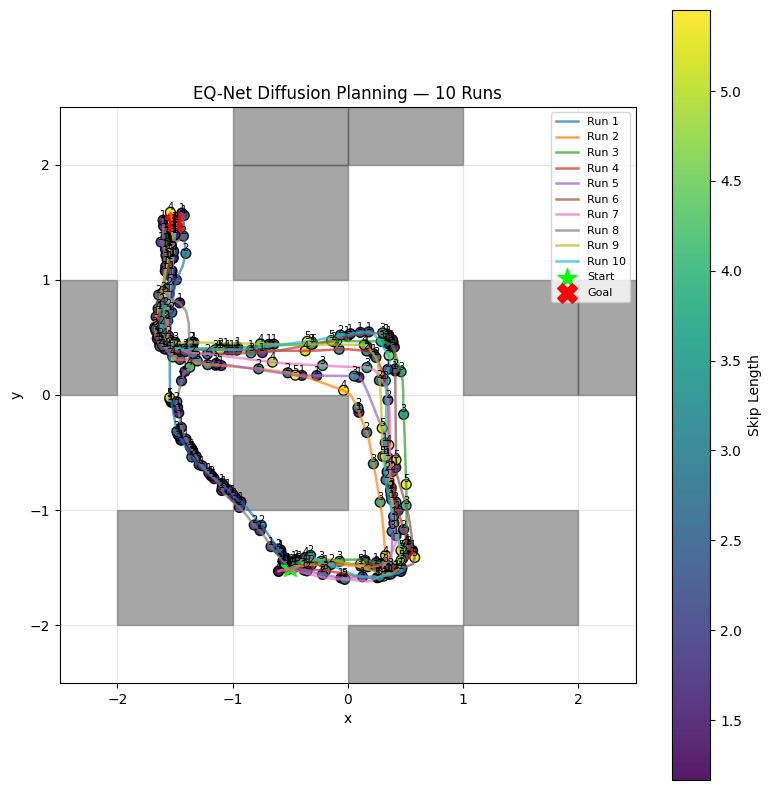

In [ ]:
# ============================================================
# CONFIG
# ============================================================
NUM_RUNS = 20
HORIZON  = 32

current = np.array([-0.5, -1.5, 0, 0])
goal    = np.array([-1.5,  1.5])

planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.0),
    ]
)

# ============================================================
# RUN PLANNING N TIMES
# ============================================================
runs = []
print(f"\nRunning {NUM_RUNS} planning attempts...\n")

for i in range(NUM_RUNS):
    print(f" → Run {i+1}/{NUM_RUNS}")

    traj = planner.plan_and_reconstruct(
        current,
        goal,
        reward_fn=reward_fn,
        horizon=HORIZON,
        guidance_scale=1.0,
        condition_on_start=True,
        condition_on_goal=True,
        conditioning_schedule="constant",
        conditioning_strength=0.9,
        spline_func=expand_spline_from_skip_list,
    )

    runs.append({
        "pos_dense": traj["pos_dense"],
        "coarse_pos": traj["coarse_pos"],
        "coarse_skip": traj["coarse_skip"],
    })

print("\nAll planning runs complete.\n")

# ============================================================
# MULTI-RUN VISUALIZER USING YOUR EXACT STYLE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Color per run (colormap)
colors = plt.cm.tab10(np.linspace(0, 1, NUM_RUNS))

# Draw MuJoCo maze walls
for geom_id in range(mj_model.ngeom):
    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)
    if name is None or ("block" not in name):
        continue

    pos  = mj_model.geom_pos[geom_id]
    size = mj_model.geom_size[geom_id]
    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# ============================================================
# Plot all trajectories
# ============================================================
for i, run in enumerate(runs):
    pos_dense   = run["pos_dense"]
    coarse_pos  = run["coarse_pos"]
    coarse_skip = run["coarse_skip"]

    color = colors[i % len(colors)]

    # 1) Dense trajectory
    ax.plot(
        pos_dense[:, 0],
        pos_dense[:, 1],
        linewidth=1.8,
        color=color,
        alpha=0.7,
        label=f"Run {i+1}"
    )

    # 2) Coarse waypoints (colored by skip)
    sc = ax.scatter(
        coarse_pos[:, 0],
        coarse_pos[:, 1],
        c=coarse_skip,
        cmap="viridis",
        s=50,
        edgecolors="k",
        alpha=0.9
    )

    # 3) Skip annotation
    for j, (x, y) in enumerate(coarse_pos):
        ax.text(x, y, f"{int(coarse_skip[j])}", fontsize=7,
                ha="center", va="bottom", color="black")

# ============================================================
# Start and goal
# ============================================================
ax.scatter(current[0], current[1], s=200, marker="*", color="lime", label="Start")
ax.scatter(goal[0],    goal[1],    s=200, marker="X", color="red",  label="Goal")

# ============================================================
# Final styling
# ============================================================
ax.set_title(f"EQ-Net Diffusion Planning — {NUM_RUNS} Runs")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8, frameon=True)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.colorbar(sc, ax=ax, label="Skip Length")
plt.tight_layout()
plt.show()